## Examples: Hyperparameters and Model validation

#### In this notebook, we'll explore hyperparameter tuning using grid search while focusing on optimising a model's performance.

### Learning Objectives
#### By the end of this notebook, you should be able to:
#### - Understand what it means to tune hyperparameters.
#### - Find optimal hyperparameters using grid search.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [3]:
mbti = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/classification_sprint/mbti_count_vector_downsampled.csv')

In [6]:
mbti.head()

,actually,agree,ask,away,bad,believe,best,better,bit,care,...,work,world,wouldnt,wrong,yeah,year,years,yes,youre,y
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [5]:
X = mbti.drop('y', axis=1)
y = mbti['y']

n = 5000
X_n = X[:n]
y_n = y[:n]

X_train, X_test, y_train, y_test = train_test_split(X_n, y_n)

### K-Nearest Neigbours

In [8]:
from sklearn.neighbors import KNeighborsClassifier

ks = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 50, 100]

results = []

for k in ks:
    print('Fitting KNN model with k = {:d}'.format(k))
    knn = KNeighborsClassifier(k)
    run_time = %timeit -q -o knn.fit(X_train, y_train)

    # predicting
    y_pred = knn.predict(X_train)
    y_pred_test = knn.predict(X_test)

    # scoring
    accuracy = metrics.accuracy_score(y_train, y_pred)
    precision = metrics.precision_score(y_train, y_pred)
    recall = metrics.recall_score(y_train, y_pred)
    f1 = metrics.f1_score(y_train, y_pred)
    f1_test = metrics.f1_score(y_test, y_pred_test)

    # Save the results
    results.append([k, accuracy, precision, recall, f1, f1_test, run_time.best])

results = pd.DataFrame(
    results,
    columns=['KNN', 'Accuracy', 'Precision', 'Recall', 'F1 Train', 'F1 Test', 'Train Time']
)
results.set_index('KNN', inplace=True)

Fitting KNN model with k = 1
Fitting KNN model with k = 2
Fitting KNN model with k = 3
Fitting KNN model with k = 4
Fitting KNN model with k = 5
Fitting KNN model with k = 6
Fitting KNN model with k = 7
Fitting KNN model with k = 8
Fitting KNN model with k = 9
Fitting KNN model with k = 10
Fitting KNN model with k = 20
Fitting KNN model with k = 50
Fitting KNN model with k = 100


In [9]:
results

,Accuracy,Precision,Recall,F1 Train,F1 Test,Train Time
KNN,,,,,,
1,0.927200,0.957869,0.947640,0.952727,0.765343,0.009167
2,0.802133,0.958033,0.778505,0.858989,0.681532,0.007979
3,0.828267,0.838681,0.963486,0.896762,0.829409,0.007458
4,0.798133,0.852034,0.894592,0.872794,0.798796,0.007762
5,0.800000,0.807308,0.974165,0.882922,0.842944,0.008183
6,0.794400,0.817829,0.944885,0.876778,0.835007,0.007847
7,0.785600,0.790479,0.983810,0.876611,0.858195,0.007243
8,0.786400,0.796725,0.972098,0.875718,0.851817,0.007638
9,0.781333,0.782786,0.993111,0.875493,0.862763,0.007380


<Axes: xlabel='KNN'>

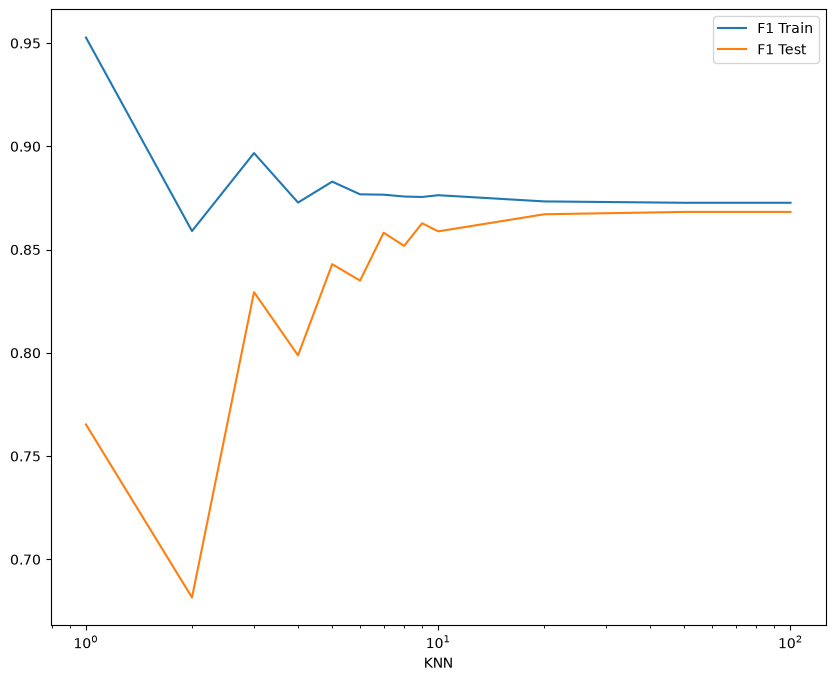

In [12]:
results[['F1 Train', 'F1 Test']].plot(kind='line', figsize=(10, 8), logx=True)

### sklearn GridSearch

In [13]:
from sklearn.model_selection import GridSearchCV

In [14]:
# ks is the list of k-values we created earlier
param_grid = {'n_neighbors': ks}

In [15]:
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, scoring='f1')

In [16]:
grid_knn.fit(X_n, y_n)
grid_knn.best_params_

{'n_neighbors': 50}

### Support Vector Machine

In [17]:
from sklearn.svm import SVC

In [19]:
nfolds = 2

Cs = [0.001, 0.01, 0.1, 1, 10]
gammas = [0.001, 0.01, 0.1, 1]

params_grid = {
    'C': Cs,
    'gamma': gammas
}

grid_SVM = GridSearchCV(SVC(), params_grid, scoring='f1', cv=nfolds)
grid_SVM.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'gamma': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with 

In [20]:
grid_SVM.best_params_

{'C': 0.001, 'gamma': 0.001}